Imports

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Device: cpu


Dataset

In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

small_val_dataset = Subset(test_dataset, list(range(1000)))
small_val_loader = DataLoader(small_val_dataset, batch_size=128, shuffle=False, num_workers=0)

print(len(train_dataset), len(test_dataset), len(small_val_dataset))

50000 10000 1000


CNN Model

In [43]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Train / Evaluate / Fine-tune

In [44]:
def evaluate_model(model, loader, device, print_result=True):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    if print_result:
        print(f"Accuracy: {acc:.2f}%")

    return acc

In [45]:
def train_model(model, train_loader, test_loader, device, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        test_acc = evaluate_model(model, test_loader, device, print_result=False)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {total_loss / len(train_loader):.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, best_acc

In [46]:
def finetune_model(model, train_loader, test_loader, device, epochs=3, lr=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = evaluate_model(model, test_loader, device, print_result=False)
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        test_acc = evaluate_model(model, test_loader, device, print_result=False)

        print(f"Fine-tune Epoch [{epoch+1}/{epochs}] Test Acc: {test_acc:.2f}%")

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, best_acc

Train Baseline

In [8]:
baseline_model = SimpleCNN().to(device)

baseline_model, baseline_accuracy = train_model(
    model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=15,
    lr=0.001
)

print("Baseline Accuracy:", baseline_accuracy)

torch.save(baseline_model.state_dict(), "../checkpoints/baseline_clean.pth")

Epoch [1/15] Loss: 1.5835 | Train Acc: 41.61% | Test Acc: 54.98%
Epoch [2/15] Loss: 1.2146 | Train Acc: 56.07% | Test Acc: 64.74%
Epoch [3/15] Loss: 1.0407 | Train Acc: 62.92% | Test Acc: 68.57%
Epoch [4/15] Loss: 0.9158 | Train Acc: 67.67% | Test Acc: 71.37%
Epoch [5/15] Loss: 0.8373 | Train Acc: 70.62% | Test Acc: 72.75%
Epoch [6/15] Loss: 0.7790 | Train Acc: 72.89% | Test Acc: 74.84%
Epoch [7/15] Loss: 0.7406 | Train Acc: 74.17% | Test Acc: 74.33%
Epoch [8/15] Loss: 0.6985 | Train Acc: 75.51% | Test Acc: 76.55%
Epoch [9/15] Loss: 0.6770 | Train Acc: 76.33% | Test Acc: 77.65%
Epoch [10/15] Loss: 0.6409 | Train Acc: 77.42% | Test Acc: 77.95%
Epoch [11/15] Loss: 0.6185 | Train Acc: 78.49% | Test Acc: 78.64%
Epoch [12/15] Loss: 0.6011 | Train Acc: 78.90% | Test Acc: 78.50%
Epoch [13/15] Loss: 0.5800 | Train Acc: 79.70% | Test Acc: 79.57%
Epoch [14/15] Loss: 0.5641 | Train Acc: 80.30% | Test Acc: 79.40%
Epoch [15/15] Loss: 0.5493 | Train Acc: 80.83% | Test Acc: 79.57%
Baseline Accuracy: 

In [9]:
baseline_model = SimpleCNN().to(device)
baseline_model.load_state_dict(torch.load("../checkpoints/baseline_clean.pth", map_location=device))
baseline_model.eval()

baseline_accuracy = evaluate_model(baseline_model, test_loader, device)
print("Reloaded Baseline Accuracy:", baseline_accuracy)

Accuracy: 79.57%
Reloaded Baseline Accuracy: 79.57


Fine-tune Baseline with Same Settings

In [47]:
baseline_ft_model = copy.deepcopy(baseline_model)

baseline_ft_model, baseline_finetuned_accuracy = finetune_model(
    model=baseline_ft_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=3,
    lr=0.0001
)

print("Original Baseline Accuracy:", baseline_accuracy)
print("Fine-tuned Baseline Accuracy:", baseline_finetuned_accuracy)
print("Baseline Fine-tune Gain:", baseline_finetuned_accuracy - baseline_accuracy)

torch.save(baseline_ft_model.state_dict(), "../checkpoints/baseline_finetuned.pth")

Fine-tune Epoch [1/3] Test Acc: 80.92%
Fine-tune Epoch [2/3] Test Acc: 80.95%
Fine-tune Epoch [3/3] Test Acc: 81.34%
Original Baseline Accuracy: 79.57
Fine-tuned Baseline Accuracy: 81.34
Baseline Fine-tune Gain: 1.7700000000000102


Pruning Utilities

In [10]:
def get_prunable_layers(model):
    layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append((name, module))

    return layers

In [11]:
prunable_layers_all = get_prunable_layers(baseline_model)

for i, (name, layer) in enumerate(prunable_layers_all):
    print(i, name, type(layer).__name__, layer.weight.numel())

0 features.0 Conv2d 864
1 features.3 Conv2d 18432
2 features.6 Conv2d 73728
3 classifier.1 Linear 524288
4 classifier.3 Linear 2560


In [12]:
prunable_layers_filtered = [
    (name, layer)
    for name, layer in prunable_layers_all
    if name != "classifier.3"
]

print("Filtered layers:")
for i, (name, layer) in enumerate(prunable_layers_filtered):
    print(i, name, type(layer).__name__, layer.weight.numel())

Filtered layers:
0 features.0 Conv2d 864
1 features.3 Conv2d 18432
2 features.6 Conv2d 73728
3 classifier.1 Linear 524288


In [13]:
def apply_layer_pruning_by_name_inplace(model, layer_name, amount):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            return model

    raise ValueError(f"Layer not found: {layer_name}")

In [14]:
def calculate_sparsity(model):
    total = 0
    zeros = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight
            total += weight.nelement()
            zeros += torch.sum(weight == 0).item()

    return 100 * zeros / total

Layer Sensitivity

In [15]:
def compute_layer_sensitivities(model, prunable_layers, loader, device, probe_amount=0.1):
    sensitivities = {}

    base_acc = evaluate_model(model, loader, device, print_result=False)
    print("Sensitivity baseline accuracy:", base_acc)

    for layer_name, _ in prunable_layers:
        temp_model = copy.deepcopy(model)

        temp_model = apply_layer_pruning_by_name_inplace(
            temp_model,
            layer_name,
            probe_amount
        ).to(device)

        pruned_acc = evaluate_model(temp_model, loader, device, print_result=False)
        drop = base_acc - pruned_acc

        sensitivities[layer_name] = drop

        print(f"{layer_name}: drop={drop:.4f}")

    return sensitivities

In [16]:
layer_sensitivities = compute_layer_sensitivities(
    model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    loader=small_val_loader,
    device=device,
    probe_amount=0.1
)

Sensitivity baseline accuracy: 79.7
features.0: drop=0.4000
features.3: drop=0.0000
features.6: drop=0.0000
classifier.1: drop=0.0000


Action Space

In [17]:
ACTION_TO_PRUNE = {
    0: 0.0,
    1: 0.1,
    2: 0.2,
    3: 0.3,
    4: 0.4,
    5: 0.6
}

State Representation

In [18]:
MAX_PARAM_COUNT = max(
    layer.weight.numel()
    for _, layer in prunable_layers_all
)

In [19]:
def extract_layer_state(
    layer,
    layer_index,
    total_layers,
    cumulative_pruning,
    layer_name,
    layer_sensitivities
):
    weights = layer.weight.detach().cpu()

    return {
        "layer_index": layer_index,
        "total_layers": total_layers,
        "param_count": weights.numel(),
        "mean_abs_weight": weights.abs().mean().item(),
        "std_weight": weights.std().item(),
        "cumulative_pruning": cumulative_pruning,
        "sensitivity": layer_sensitivities.get(layer_name, 0.0)
    }

In [20]:
def state_to_vector(state):
    return np.array([
        state["layer_index"] / max(1, state["total_layers"] - 1),
        np.log1p(state["param_count"]),
        state["param_count"] / MAX_PARAM_COUNT,
        state["mean_abs_weight"],
        state["std_weight"],
        state["cumulative_pruning"],
        state["sensitivity"]
    ], dtype=np.float32)

Reward Function for Accuracy Above Baseline
This reward tries to push accuracy recovery through fine-tuning.

In [21]:
def compute_reward(final_accuracy, baseline_accuracy, sparsity, actions=None):
    acc_gain = final_accuracy - baseline_accuracy

    reward = 0.04 * sparsity

    if acc_gain >= 0:
        reward += 5.0 + acc_gain
    else:
        reward += acc_gain * 2.0

    if actions is not None:
        reward += 0.05 * len(set(actions))

    return reward

Gym Environment with Fine-tuning
Each final pruned model is fine-tuned before reward calculation.

In [31]:
class CompressionEnvGymFineTune(gym.Env):
    def __init__(
        self,
        base_model,
        prunable_layers,
        baseline_accuracy,
        eval_loader,
        finetune_loader,
        device,
        layer_sensitivities,
        finetune_epochs=1,
        finetune_lr=0.0001
    ):
        super().__init__()

        self.base_model = base_model
        self.prunable_layers_info = [
            (name, type(layer).__name__)
            for name, layer in prunable_layers
        ]

        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.eval_loader = eval_loader
        self.finetune_loader = finetune_loader
        self.device = device
        self.layer_sensitivities = layer_sensitivities

        self.finetune_epochs = finetune_epochs
        self.finetune_lr = finetune_lr

        self.action_space = spaces.Discrete(len(ACTION_TO_PRUNE))

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32
        )

        self.current_model = None
        self.current_layer_index = 0
        self.cumulative_pruning = 0.0
        self.actions_taken = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_model = copy.deepcopy(self.base_model)
        self.current_layer_index = 0
        self.cumulative_pruning = 0.0
        self.actions_taken = []

        return self._get_state(), {}

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return np.zeros((7,), dtype=np.float32)

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    layer=module,
                    layer_index=self.current_layer_index,
                    total_layers=self.total_layers,
                    cumulative_pruning=self.cumulative_pruning,
                    layer_name=name,
                    layer_sensitivities=self.layer_sensitivities
                )
                return state_to_vector(state)

        raise ValueError(f"Layer not found: {layer_name}")

    def step(self, action):
        action = int(action)

        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.actions_taken.append(action)
        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        terminated = self.current_layer_index >= self.total_layers
        truncated = False

        if terminated:
            # IMPORTANT:
            # Do not deepcopy after pruning masks are attached.
            # Use the already-copied episode model.
            tuned_model = self.current_model

            tuned_model, tuned_accuracy = finetune_model(
                model=tuned_model,
                train_loader=self.finetune_loader,
                test_loader=self.eval_loader,
                device=self.device,
                epochs=self.finetune_epochs,
                lr=self.finetune_lr
            )

            final_sparsity = calculate_sparsity(tuned_model)

            reward = compute_reward(
                final_accuracy=tuned_accuracy,
                baseline_accuracy=self.baseline_accuracy,
                sparsity=final_sparsity,
                actions=self.actions_taken
            )

            obs = np.zeros((7,), dtype=np.float32)

            info = {
                "final_accuracy": tuned_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward,
                "actions": self.actions_taken
            }

        else:
            obs = self._get_state()
            reward = 0.0
            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return obs, reward, terminated, truncated, info

Check Environment

In [32]:
train_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=small_val_loader,
    finetune_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=1,
    finetune_lr=0.0001
)

obs, info = train_env.reset()
result = train_env.step(1)

print("Obs shape:", obs.shape)
print("Step len:", len(result))
print(result)

Obs shape: (7,)
Step len: 5
(array([0.33333334, 9.8218975 , 0.03515625, 0.05962399, 0.07835707,
       0.1       , 0.        ], dtype=float32), 0.0, False, False, {'current_layer': 'features.0', 'prune_amount': 0.1})


In [33]:
check_env(train_env, warn=True)
print("Environment check passed")

Fine-tune Epoch [1/1] Test Acc: 81.60%
Fine-tune Epoch [1/1] Test Acc: 51.80%
Environment check passed


PPO Training with Fine-tuning Env

In [34]:
train_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=small_val_loader,
    finetune_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=1,
    finetune_lr=0.0001
)

agent = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=32,
    batch_size=16,
    n_epochs=5,
    gamma=0.99,
    ent_coef=0.02,
    seed=SEED
)

agent.learn(total_timesteps=300)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Fine-tune Epoch [1/1] Test Acc: 81.20%
Fine-tune Epoch [1/1] Test Acc: 81.30%
Fine-tune Epoch [1/1] Test Acc: 51.60%
Fine-tune Epoch [1/1] Test Acc: 50.80%
Fine-tune Epoch [1/1] Test Acc: 78.50%
Fine-tune Epoch [1/1] Test Acc: 52.00%
Fine-tune Epoch [1/1] Test Acc: 81.10%
Fine-tune Epoch [1/1] Test Acc: 49.20%
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4        |
|    ep_rew_mean     | -24.7    |
| time/              |          |
|    fps             | 0        |
|    iterations      | 1        |
|    time_elapsed    | 39       |
|    total_timesteps | 32       |
---------------------------------
Fine-tune Epoch [1/1] Test Acc: 77.40%
Fine-tune Epoch [1/1] Test Acc: 81.60%
Fine-tune Epoch [1/1] Test Acc: 49.60%
Fine-tune Epoch [1/1] Test Acc: 73.80%
Fine-tune Epoch [1/1] Test Acc: 78.30%
Fine-tune Epoch [1/1] Test Acc: 81.30%
Fine-tune Epoch [1/1

Evaluation Env with Full Test Set

In [35]:
eval_env = CompressionEnvGymFineTune(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=test_loader,
    finetune_loader=train_loader,
    device=device,
    layer_sensitivities=layer_sensitivities,
    finetune_epochs=3,
    finetune_lr=0.0001
)

Evaluate Trained Agent

In [36]:
def evaluate_trained_agent(agent, env, policy_name):
    obs, info = env.reset()

    done = False
    chosen_actions = []

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        action = int(action)

        chosen_actions.append(action)

        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(chosen_actions),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(result)
    return result

In [37]:
ppo_finetune_result = evaluate_trained_agent(
    agent=agent,
    env=eval_env,
    policy_name="PPO_FineTune"
)

ppo_finetune_result

Fine-tune Epoch [1/3] Test Acc: 80.88%
Fine-tune Epoch [2/3] Test Acc: 81.12%
Fine-tune Epoch [3/3] Test Acc: 81.33%
{'Method': 'PPO_FineTune', 'Actions': '[2, 2, 2, 2]', 'Accuracy (%)': 81.33, 'Sparsity (%)': 19.917499096587683, 'Reward': 7.606699963863512}


{'Method': 'PPO_FineTune',
 'Actions': '[2, 2, 2, 2]',
 'Accuracy (%)': 81.33,
 'Sparsity (%)': 19.917499096587683,
 'Reward': 7.606699963863512}

Manual Baselines with Fine-tuning

In [38]:
def run_fixed_policy_finetune(policy, policy_name):
    env = CompressionEnvGymFineTune(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_accuracy,
        eval_loader=test_loader,
        finetune_loader=train_loader,
        device=device,
        layer_sensitivities=layer_sensitivities,
        finetune_epochs=3,
        finetune_lr=0.0001
    )

    obs, info = env.reset()
    done = False
    step_idx = 0

    while not done:
        action = policy[step_idx]

        obs, reward, terminated, truncated, info = env.step(action)

        step_idx += 1
        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(policy),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(result)
    return result

In [39]:
manual_ft_results = []

manual_ft_results.append(run_fixed_policy_finetune([1, 1, 1, 1], "FT Uniform 10%"))
manual_ft_results.append(run_fixed_policy_finetune([2, 2, 2, 2], "FT Uniform 20%"))
manual_ft_results.append(run_fixed_policy_finetune([4, 4, 4, 4], "FT Uniform 40%"))
manual_ft_results.append(run_fixed_policy_finetune([5, 5, 5, 5], "FT Uniform 60%"))

Fine-tune Epoch [1/3] Test Acc: 81.08%
Fine-tune Epoch [2/3] Test Acc: 80.81%
Fine-tune Epoch [3/3] Test Acc: 81.01%
{'Method': 'FT Uniform 10%', 'Actions': '[1, 1, 1, 1]', 'Accuracy (%)': 81.08, 'Sparsity (%)': 9.958668886479789, 'Reward': 6.958346755459196}
Fine-tune Epoch [1/3] Test Acc: 80.81%
Fine-tune Epoch [2/3] Test Acc: 81.03%
Fine-tune Epoch [3/3] Test Acc: 80.95%
{'Method': 'FT Uniform 20%', 'Actions': '[2, 2, 2, 2]', 'Accuracy (%)': 81.03, 'Sparsity (%)': 19.917499096587683, 'Reward': 7.306699963863515}
Fine-tune Epoch [1/3] Test Acc: 80.37%
Fine-tune Epoch [2/3] Test Acc: 80.53%
Fine-tune Epoch [3/3] Test Acc: 80.77%
{'Method': 'FT Uniform 40%', 'Actions': '[4, 4, 4, 4]', 'Accuracy (%)': 80.77, 'Sparsity (%)': 39.83483686954726, 'Reward': 7.843393474781894}
Fine-tune Epoch [1/3] Test Acc: 78.29%
Fine-tune Epoch [2/3] Test Acc: 79.53%
Fine-tune Epoch [3/3] Test Acc: 79.86%
{'Method': 'FT Uniform 60%', 'Actions': '[5, 5, 5, 5]', 'Accuracy (%)': 79.86, 'Sparsity (%)': 59.7521

Final Comparison

In [48]:
baseline_row = {
    "Method": "Baseline",
    "Actions": "-",
    "Accuracy (%)": baseline_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_accuracy,
        baseline_accuracy=baseline_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

baseline_ft_row = {
    "Method": "Baseline + Fine-tune",
    "Actions": "-",
    "Accuracy (%)": baseline_finetuned_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_finetuned_accuracy,
        baseline_accuracy=baseline_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

final_results_df = pd.DataFrame(
    [baseline_row, baseline_ft_row] + manual_ft_results + [ppo_finetune_result]
)

final_results_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,Baseline,-,79.57,0.000000,5.050000
1,Baseline + Fine-tune,-,81.34,0.000000,6.820000
2,FT Uniform 10%,"[1, 1, 1, 1]",81.08,9.958669,6.958347
3,FT Uniform 20%,"[2, 2, 2, 2]",81.03,19.917499,7.306700
4,FT Uniform 40%,"[4, 4, 4, 4]",80.77,39.834837,7.843393
5,FT Uniform 60%,"[5, 5, 5, 5]",79.86,59.752175,7.730087
6,PPO_FineTune,"[2, 2, 2, 2]",81.33,19.917499,7.606700


Check if RL Beats Baseline

In [49]:
ppo_acc = ppo_finetune_result["Accuracy (%)"]

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Fine-tuned Accuracy:", baseline_finetuned_accuracy)
print("PPO FineTune Accuracy:", ppo_acc)

print("PPO - Baseline:", ppo_acc - baseline_accuracy)
print("PPO - Baseline Fine-tuned:", ppo_acc - baseline_finetuned_accuracy)

if ppo_acc > baseline_finetuned_accuracy:
    print("SUCCESS: PPO FineTune is better than fair fine-tuned baseline.")
elif ppo_acc > baseline_accuracy:
    print("PARTIAL SUCCESS: PPO FineTune beats original baseline but not fine-tuned baseline.")
else:
    print("Not better yet. Try more PPO steps, more fine-tuning epochs, or lower pruning.")

Baseline Accuracy: 79.57
Baseline Fine-tuned Accuracy: 81.34
PPO FineTune Accuracy: 81.33
PPO - Baseline: 1.7600000000000051
PPO - Baseline Fine-tuned: -0.010000000000005116
PARTIAL SUCCESS: PPO FineTune beats original baseline but not fine-tuned baseline.


In [50]:
final_results_df.to_csv("../results/final_results_fair_finetune.csv", index=False)

agent.save("../checkpoints/ppo_finetune_agent_fair")

torch.save(baseline_ft_model.state_dict(), "../checkpoints/baseline_finetuned.pth")

print("Saved final fair results and models.")

Saved final fair results and models.


Plot Results

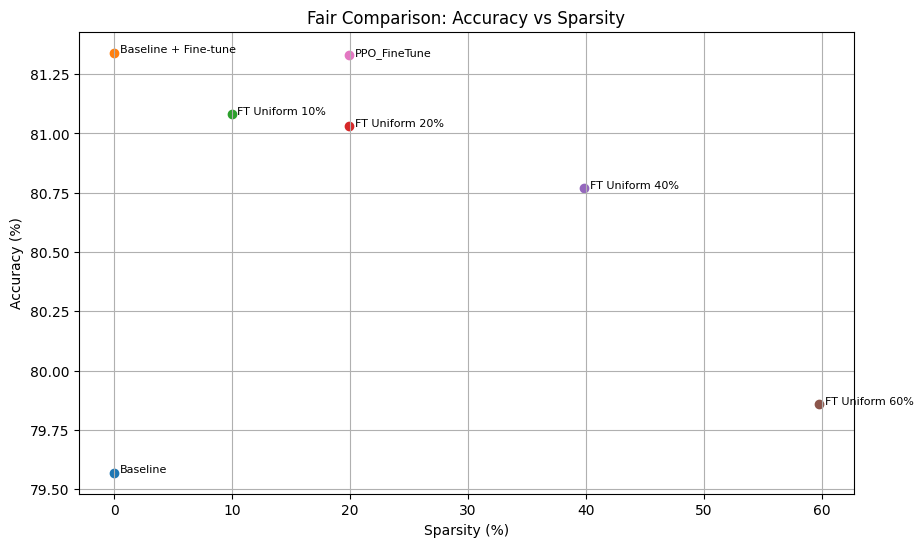

In [51]:
plt.figure(figsize=(10, 6))

for _, row in final_results_df.iterrows():
    plt.scatter(row["Sparsity (%)"], row["Accuracy (%)"])
    plt.text(
        row["Sparsity (%)"] + 0.5,
        row["Accuracy (%)"],
        row["Method"],
        fontsize=8
    )

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Fair Comparison: Accuracy vs Sparsity")
plt.grid(True)
plt.show()

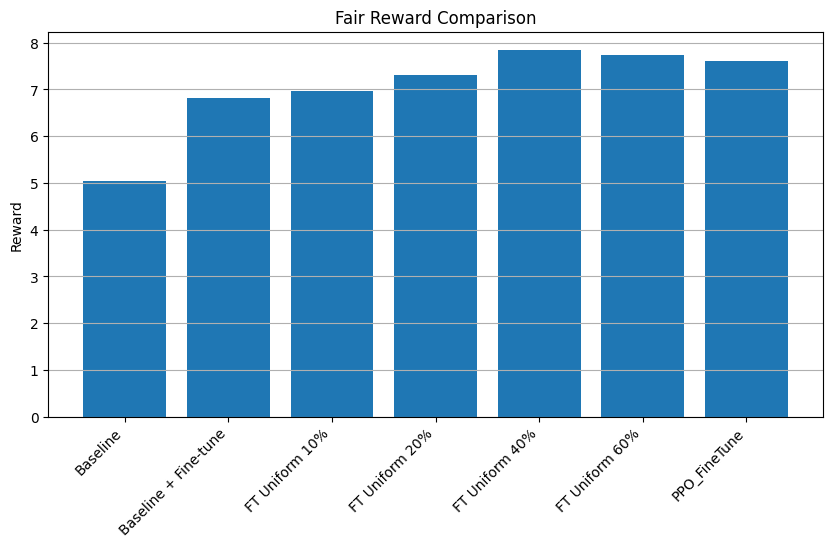

In [52]:
plt.figure(figsize=(10, 5))

plt.bar(final_results_df["Method"], final_results_df["Reward"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Reward")
plt.title("Fair Reward Comparison")
plt.grid(axis="y")
plt.show()